# Alternative Ensemble-Detection Methods: RICA and CRF

**Objective:** benchmark the PCA + k-means approach against two alternative methods for identifying neural ensembles.

**Method:** apply Reconstruction ICA (RICA, with pre-whitening) to extract independent components as candidate ensemble "features," project trials onto the top components, cluster, and map feature weights back onto ROI spatial position and whisker tuning. Also set up Conditional Random Fields (CRF), the method used by the Yuste Lab for ensemble detection, as a further comparison point.


# Alternative Ensemble Analysis Methods

## 1. Reconstruction Independent Component Analysis - RICA

RICA learns a linear transformation a t x f, where t is number of obeservation or trials and f is the number of features to be extracted from population array. The transformation is based on optimizing a nonlinear objective function that roughly balances statistical independence of the output features versus the ability to reconstruct the input data using the output features.

In [189]:
% load data
addpath('matlab','data')
load('calcium_data.mat')
load('stimuli_info.mat')
load ('data_stimsorted.mat')
load('ROI_positions.mat')

In [182]:
%Variables
thrld = 0.25;
fov = 4; % 1 of 8 FOV
tbin = 0.5; % 1 second time bin
stim_onset = 5;
num_rois = numel(fieldnames(dat_sorted{fov}.deNoise_dff));
stimulus = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1', 'blank'};

## Note on Pre-whitening before ICA

Before performing ICA, the input data is usually whitened to remove any correlation. The data is transformed to have zero mean and identity covariance in order to get statistically independent dimensions (neurons): P(A n B) = P(A)P(B).

Forcing all dimensions to have unit variance treats each dimension with equal importance.

With that in mind, it will not be useful to treat all neurons with equal importance, removes the interesting correlations we seek to find. Could think of doing some other pre-processing step that removes "un-important" neurons. 

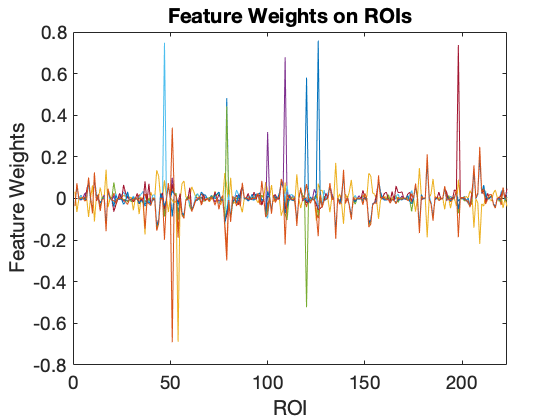

In [117]:
% Get Population Array
t_start = 8;
frameRate = 7.4811;
t_end = t_start + round(tbin*frameRate);

[stim_PA, stim_label] = get_stim_PA(dat_sorted,fov,thrld,t_start,tbin);
[stim_PA_zscore, mu, sigma] = zscore(stim_PA);

prewhiten_stimPA = prewhiten(stim_PA); % try pre-whitening, no luck 

% Num of Features to Extract 
nfeatures = 9; % Choose 9 to start with, 9 stimuli 
RICAmodel = rica(stim_PA-mu, nfeatures, 'NonGaussianityIndicator', ones(nfeatures,1)); % subtract mean and indicate original ensembles as non-gaussian


figure(1)
plot(RICAmodel.TransformWeights)
xlabel('ROI')
ylabel('Feature Weights')
xlim([0,223])
set(gca,'FontSize', 14)
title('Feature Weights on ROIs')

_Notes_:
- stability of features is improved when subtracting mu and specifying sub-gaussian features to be extracted
    - however features are somewhat unstable after succesive runs of the algorithm
    
## Whisker Tuning for Cells in each Feature

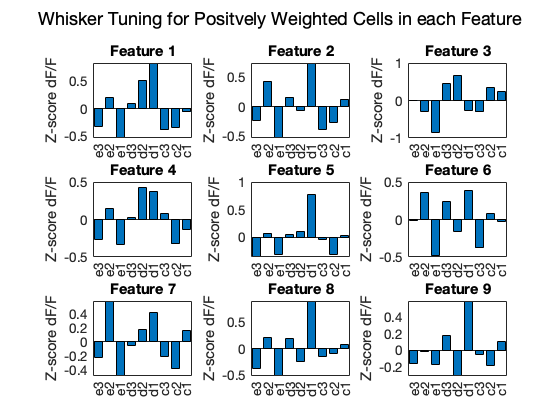

In [158]:
% Whisker Tuning for Cells heavily weighted in PC
cutoff = 0.1;
for PC = 1:size(RICAmodel.TransformWeights,2)
    PC_weights{PC}.rois = find(RICAmodel.TransformWeights(:,PC) > cutoff);
    PC_weights{PC}.dff_max = zeros(length(PC_weights{PC}.rois),9);
    for nrois = 1:length(PC_weights{PC}.rois)
        roi = ['ROI', num2str(PC_weights{PC}.rois(nrois))];
        for stim_num = 1:length(stimulus)-1
            stim = stimulus{stim_num};
            dff_stim = dat_sorted{fov}.deNoise_dff.(roi).(stim);
            PC_weights{PC}.dff_max(nrois,stim_num) = mean(max(dff_stim(:,t_start:t_end),[],2));
        end
    end 
end

%Plot whisker tuning for each ROI weighted strongly in first few PCs  

whiskers = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1'};
x = categorical(whiskers);
x = reordercats(x, whiskers);

% Mean Whisker Receptive Field for ROIs in Cluster

for PC = 1:size(RICAmodel.TransformWeights,2)
    y = zscore(PC_weights{PC}.dff_max,[],2);
    whisk_resp_avg = mean(y,1);
    subplot(3,3,PC)
    set(gca,'FontSize', 14)
    bar(x,whisk_resp_avg)
    ylabel('Z-score dF/F')
    title(['Feature ', num2str(PC)])
end
sgtitle('Whisker Tuning for Positvely Weighted Cells in each Feature')

## Ensemble Activity during Single Whisker Deflection Trials

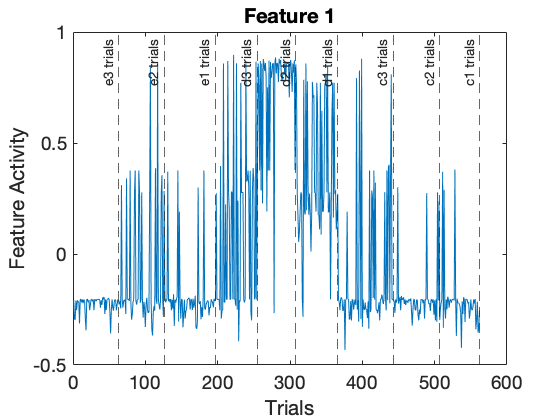

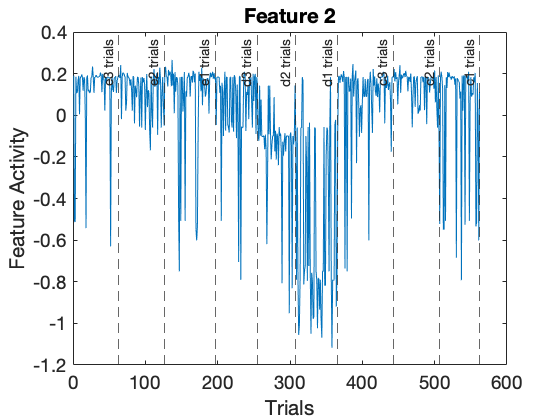

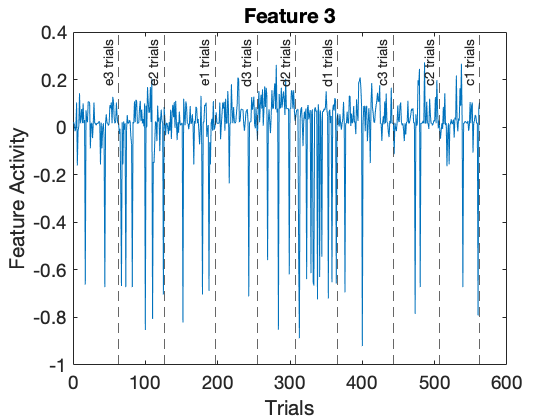

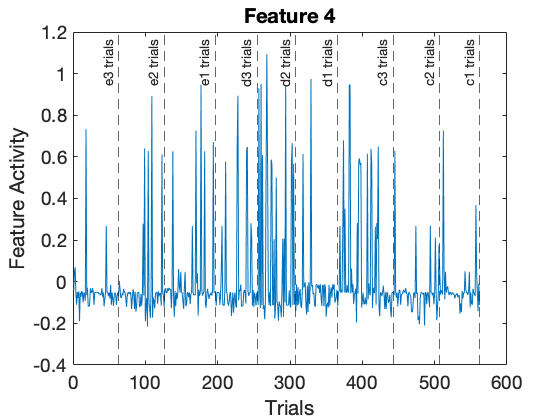

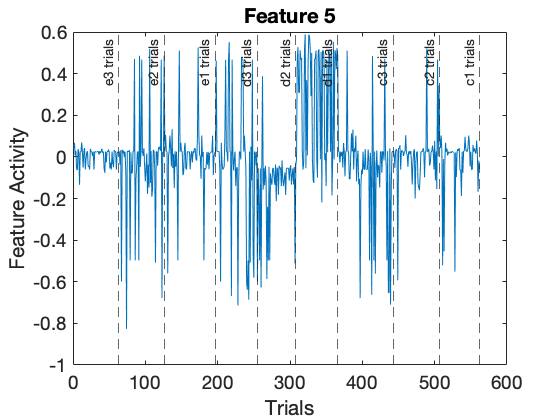

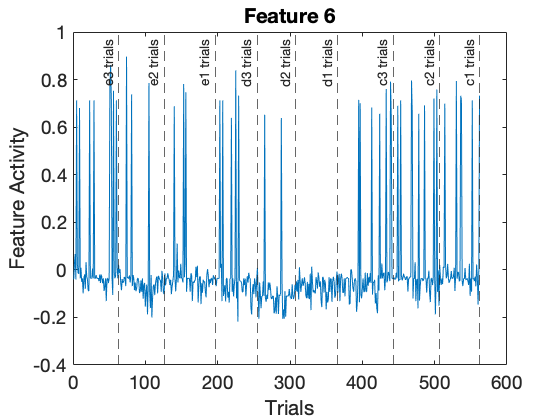

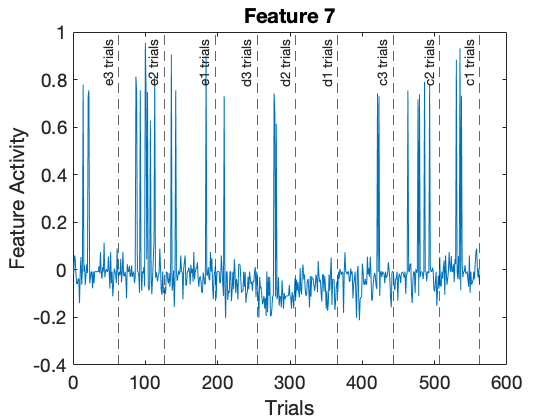

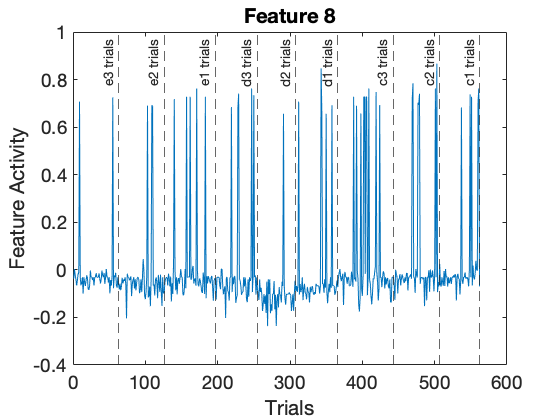

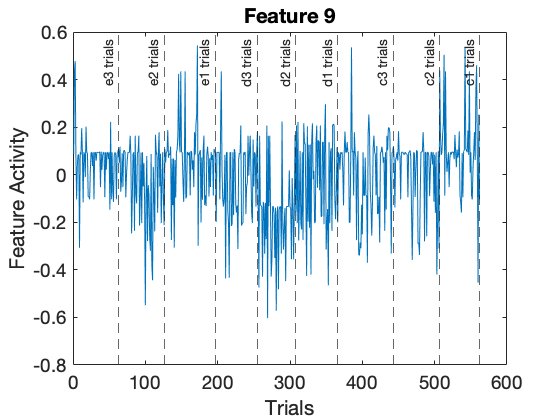

In [163]:
% Map input data into new feature space

ensemble_activity = transform(RICAmodel,stim_PA-mu);
stim_start = cumsum(pa_size);

for features = 1:nfeatures
    figure(features)
    plot(ensemble_activity(:,features))
    set(gca,'FontSize', 14)
    xlabel('Trials')
    ylabel('Feature Activity')
    for stim = 1: length(stimulus)-1
       xline(stim_start(stim),'--',[stimulus{stim}, ' trials'],'LabelHorizontalAlignment', 'left');
    end
    title(['Feature ', num2str(features)])
end

## Feature Weights in Space

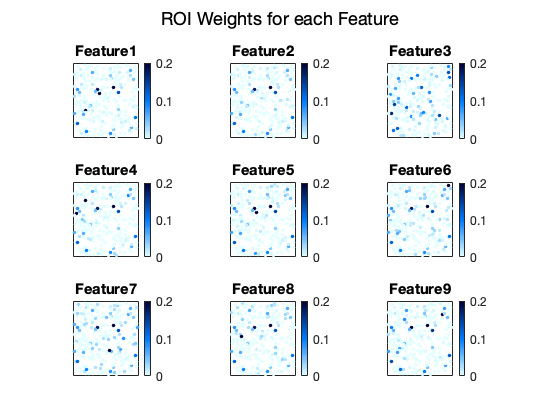

In [139]:
%Plot average dF/F on map of ROIs

% Get ROI Positions 
x_pst = zeros(numel(fields(ROI_position{fov}.ROI_centroids)),1);
y_pst = zeros(numel(fields(ROI_position{fov}.ROI_centroids)),1);
% x_pst = zeros(num_rois,1);
% y_pst = zeros(num_rois,1);
for i = 1:numel(fields(ROI_position{fov}.ROI_centroids))
    roi = ['ROI', num2str(i)];
    x_pst(i) = ROI_position{fov}.ROI_centroids.(roi)(1);
    y_pst(i) = ROI_position{fov}.ROI_centroids.(roi)(2);
end

for clust = 1:nfeatures
    subplot(3,3,clust)
    plot_clusteronROIS(x_pst, y_pst, RICAmodel.TransformWeights(:,clust), ['Feature',num2str(clust)],8)
    caxis([0,0.2])
    
end
sgtitle('ROI Weights for each Feature')

## ROI weights for each features 

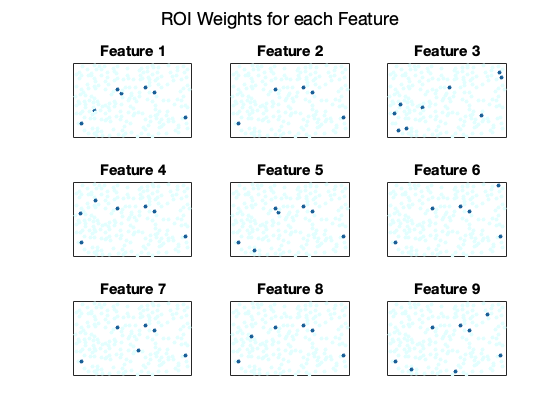

In [155]:
%Plot average dF/F on map of ROIs

cmap_ROIS = [227/256, 255/256, 255/256;
            0.100,0.371,0.592];

for clust = 1:nfeatures
    PC = zeros(num_rois,1);
    PC(PC_weights{clust}.rois) = 1;
    
    subplot(3,3,clust)
    scatter(x_pst, y_pst, 10, PC, 'filled')
    xlim([0,513])
    ylim([0,513])
    set(gca,'xtick',[])
    set(gca,'ytick',[])
    box on
    colormap(cmap_ROIS)
%     set(gca,'FontSize', 14)
    title(['Feature ', num2str(clust)])
end
sgtitle('ROI Weights for each Feature')

# Feature 1 and 5 Projection

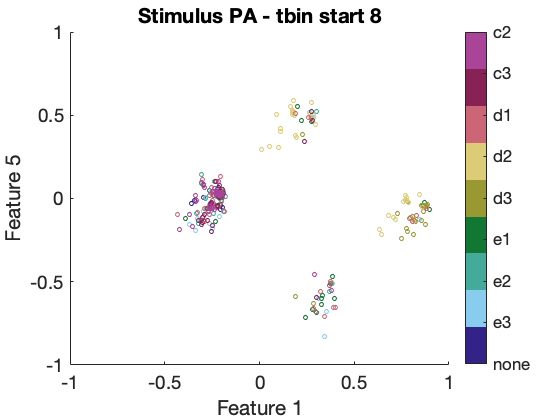

In [194]:
plot_PCAscores(ensemble_activity(:,1),ensemble_activity(:,5), stim_label, ['Stimulus PA - tbin start ',num2str(t_start)])
xlim([-1,1])
ylim([-1,1])
cmap = ptc12(9);
colormap(cmap(1:9,:))
set(gca,'FontSize', 14)
bcolumns = {'none','e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1'};
colorbar('TickLabels', bcolumns)
xlabel('Feature 1')
ylabel('Feature 5')

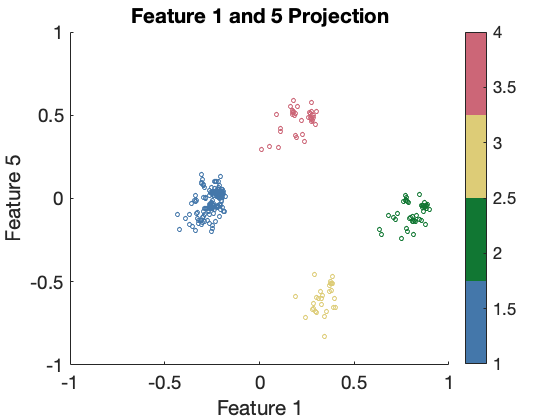

In [202]:
%K-means on PC Data
cluster_num = 4;
featuresk = [ensemble_activity(:,1), ensemble_activity(:,5)];

[cluster_lbls,centroid_locs,sumd] = kmeans(featuresk, cluster_num, 'Distance', 'sqeuclidean');

plot_PCA(featuresk, cluster_lbls, 'Feature 1 and 5 Projection')
xlim([-1,1])
ylim([-1,1])
cmap = ptc12(4);
colormap(cmap(1:4,:))
set(gca,'FontSize', 14)
% colorbar('off') 
xlabel('Feature 1')
ylabel('Feature 5')

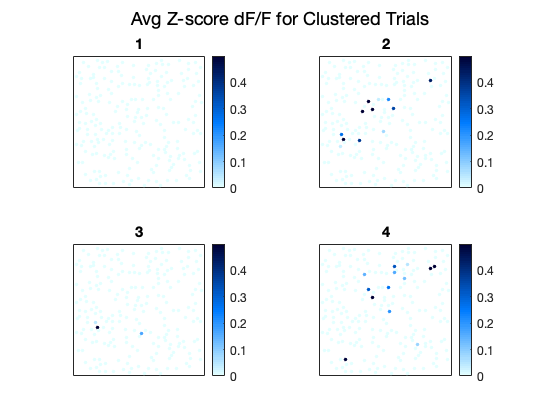

In [203]:
% Get dFF for all trials within cluster 
cluster_info = cluster_idxs(dat_sorted,fov, cluster_lbls, stim_label);
[cluster_info,cluster_dff_avg, cluster_dff_avg_norm] = get_dff_cluster(data, dat_sorted, fov, cluster_info, tbin);     

% Z-score dF/F

for clust = 1:length(cluster_info)
    subplot(2,2,clust)
    plot_clusteronROIS(x_pst, y_pst, cluster_dff_avg_norm(:,clust), [num2str(clust)],8)
end
sgtitle('Avg Z-score dF/F for Clustered Trials')

## Tuning for Cells in each cluster 

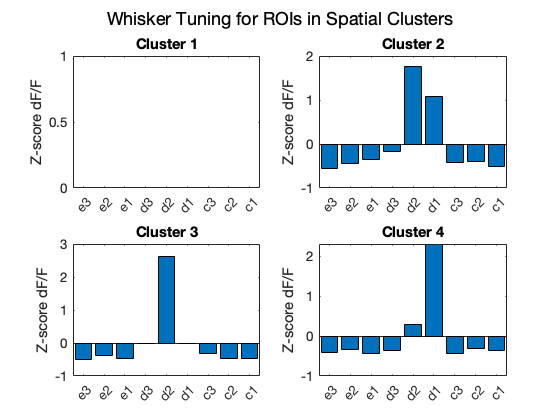

In [206]:
% Get dF/F for Cells within Cluster for each whisker stimulus type 
cutoff = 0.2;
spatial_clusters = get_spatial_cluster(dat_sorted, data, cluster_dff_avg_norm, cutoff, cluster_num, fov, t_start, tbin);

%Plot whisker tuning for each ROI in each cluster for all clusters  

whiskers = {'e3', 'e2', 'e1', 'd3', 'd2', 'd1', 'c3', 'c2', 'c1'};
x = categorical(whiskers);
x = reordercats(x, whiskers);

% Mean Whisker Receptive Field for ROIs in Cluster

for clusters = 1: length(spatial_clusters)
    y = zscore(spatial_clusters{clusters}.dff_max,[],2);
    whisk_resp_avg = mean(y,1);
    subplot(2,2,clusters)
    bar(x,whisk_resp_avg)
    ylabel('Z-score dF/F')
    title(['Cluster ', num2str(clusters)])
end
sgtitle('Whisker Tuning for ROIs in Spatial Clusters')

## Tuning for Cells Unique to each Cluster


ans =

    51
    78
    79
   120
   123
   149
   182
   190
   207


ans =

    51
    52
    78
    79
   151
   182
   211



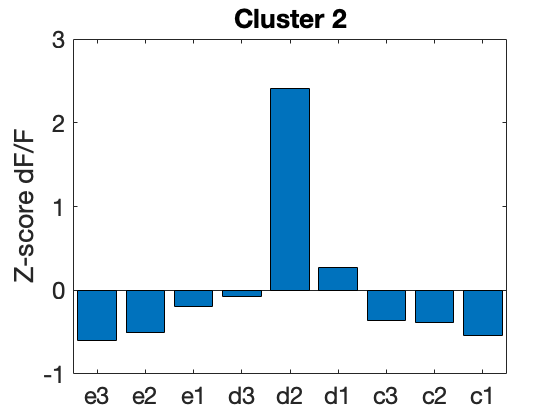

In [239]:
spatial_clusters{2}.rois
spatial_clusters{4}.rois
unique1 = [spatial_clusters{2}.dff_max(4:6,:); spatial_clusters{2}.dff_max(8:9,:)];
unique2 = [spatial_clusters{4}.dff_max(2,:); spatial_clusters{4}.dff_max(5,:); spatial_clusters{4}.dff_max(7,:)];

    y = zscore(unique1,[],2);
    whisk_resp_avg = mean(y,1);
    figure(1)
    bar(x,whisk_resp_avg)
    ylabel('Z-score dF/F')
    set(gca,'FontSize', 18)
    title('Cluster 2')
%     title(['Cluster ', num2str(clusters)])
% sgtitle('Whisker Tuning for ROIs in Spatial Clusters')

Questions / Concerns
- not sure how to choose number of features? Assume the same number of ensembles as types of stimuli
    - distribution of weight on number of neurons increases with increasing feature number
- 

## 2. Conditional Random Fields - Yuste Lab Method

Save stimului and population array for the analysis

In [16]:
% save data array 
fov = 4;
[stim_PA, stim_label] = get_stim_PA(dat_sorted,fov,thrld,t_start,tbin);
data = stim_PA;

% save stimulus array 
pa_size = zeros(length(stimulus)-1,1);
stim_array = [];
for stim_num = 1: length(stimulus)-1
    stim = stimulus{stim_num};
    pa_size(stim_num) = length(dat_sorted{fov}.dff.ROI1.(stim));
    stim_indiv = zeros(pa_size(stim_num),length(stimulus)-1);
    stim_indiv(:,stim_num) = ones(pa_size(stim_num),1);
    stim_array = cat(1,stim_array,stim_indiv);
end
stimuli = stim_array;
% save('fov8_9whisk.mat','data','stimuli')